In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import scipy.stats
%matplotlib inline

In [4]:
#Save all Recall objects as pickle
import pickle
# List of objects to save
astros = [3, 4, 5, 6, 7, 8, 9]  # Add all the astros you want to save to this list

# Loop through each astro and save it
for i, astro in enumerate(astros, start=1):
    filename = f'/Users/suthardr/Desktop/astro{i+2}_fc.pkl'
    with open(filename, 'rb') as filehandler:
        globals()[f'astro{i+2}fc'] = pickle.load(filehandler)
    print(f'Astro {i+2} loaded successfully.')

Astro 3 loaded successfully.
Astro 4 loaded successfully.
Astro 5 loaded successfully.
Astro 6 loaded successfully.
Astro 7 loaded successfully.
Astro 8 loaded successfully.
Astro 9 loaded successfully.


In [2]:
astro_4_fc = onep.InscopixProcessing(session='fc', animal='astro3',data_directory='/Users/suthardr/Desktop/')
astro_4_recall = onep.InscopixProcessing(session='recall', animal='astro3', data_directory='/Users/suthardr/Desktop/')

/Users/suthardr/Documents/GitHub/dCA1_Paper/onep/onephoton.py:76: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,2

In [3]:
#Get registration table
table = astro_3_fc.load_registration_table(session_subset=[0,1],filter_accepted=True)

only sessions: 
['fc', 'recall']
Loading in registration table for only: 
['fc', 'recall']


In [4]:
print(table)

     0    1
0    0   -1
1    1  143
2    2   26
3    3   10
4    4  216
..  ..  ...
327 -1  257
328 -1  129
329 -1  201
330 -1    4
331 -1  262

[332 rows x 2 columns]


In [5]:
#Filter by cells only in both days
both_idxs = table.loc[(table[0]!=-1)&(table[1]!=-1)]

In [6]:
both_idxs

,0,1
1,1,143
2,2,26
3,3,10
4,4,216
6,6,2
...,...,...
178,179,243
179,180,258
182,183,245
184,185,89


In [7]:
fc_traces = astro_3_fc.get_traces()
recall_traces = astro_3_recall.get_traces() #important to use this function and not index into object.accepted traces bc 'table' is in reference to all the traces.

In [8]:
fc_traces

array([[ 0.08017123,  0.07851045,  0.07366558, ...,  0.00031725,
        -0.00111023, -0.00170515],
       [ 0.03156654,  0.02953099,  0.02669217, ..., -0.00681656,
        -0.00824349, -0.00747554],
       [ 0.09387168,  0.08676338,  0.07182521, ..., -0.00321287,
        -0.00264956, -0.00644976],
       ...,
       [-0.06592773, -0.05681901, -0.05473351, ...,  0.0347509 ,
         0.0306253 ,  0.03153411],
       [ 0.0054474 ,  0.00570104,  0.00594904, ..., -0.00040198,
        -0.00129185, -0.00145666],
       [-0.0011565 ,  0.00137904, -0.0023611 , ...,  0.00032929,
        -0.0020379 ,  0.00228144]])

In [9]:
recall_traces


array([[ 3.623633e-01,  3.391954e-01,  3.197538e-01, ...,  3.069460e-03,
         2.483525e-03, -3.591898e-03],
       [ 1.582349e-02,  2.204848e-02,  2.368530e-02, ..., -6.678378e-03,
        -4.082931e-03, -6.437188e-04],
       [ 1.375123e-02,  1.514639e-02,  1.141487e-02, ..., -2.770985e-03,
         3.779565e-04, -4.948122e-03],
       ...,
       [ 5.714456e-02,  5.722363e-02,  5.420573e-02, ..., -5.096548e-03,
        -5.537684e-03, -8.158626e-03],
       [ 9.584354e-03,  1.118584e-02,  6.966728e-03, ..., -2.725890e-04,
        -6.881339e-04, -5.147358e-03],
       [-7.498940e-04,  2.724632e-03,  1.020257e-02, ..., -2.129874e-03,
         2.986961e-03, -3.045759e-04]])

In [10]:
fc_active = fc_traces[both_idxs[0]]
fc_active

array([[ 0.03156654,  0.02953099,  0.02669217, ..., -0.00681656,
        -0.00824349, -0.00747554],
       [ 0.09387168,  0.08676338,  0.07182521, ..., -0.00321287,
        -0.00264956, -0.00644976],
       [ 0.0511072 ,  0.04621322,  0.04765987, ..., -0.00856388,
        -0.00678188, -0.00756516],
       ...,
       [-0.06592773, -0.05681901, -0.05473351, ...,  0.0347509 ,
         0.0306253 ,  0.03153411],
       [-0.0011565 ,  0.00137904, -0.0023611 , ...,  0.00032929,
        -0.0020379 ,  0.00228144],
       [-0.00833454, -0.01391749, -0.01389726, ..., -0.0106444 ,
        -0.01246034, -0.01244202]])

In [11]:
recall_active = recall_traces[both_idxs[1]]
recall_active

array([[-0.03077061, -0.02943727, -0.02856196, ...,  0.00174955,
        -0.00062735, -0.00292619],
       [ 0.04469064,  0.03889294,  0.03646424, ...,  0.00038239,
         0.00392302,  0.0022093 ],
       [ 0.02051254,  0.01500712,  0.01079198, ..., -0.00819058,
        -0.00208507, -0.00081269],
       ...,
       [-0.02132748, -0.01992465, -0.02162052, ..., -0.01384155,
        -0.00453127,  0.00112764],
       [ 0.01614533,  0.01429928,  0.01947797, ..., -0.01255453,
        -0.01203727, -0.01021818],
       [-0.02168169, -0.02067128, -0.01722541, ...,  0.01445302,
         0.01002462,  0.00961226]])

In [12]:
fc_dfz = stats.zscore(fc_active, axis=1)
fc_dfz

array([[ 2.85046464,  2.66665409,  2.41030809, ..., -0.61553668,
        -0.74438918, -0.67504288],
       [ 7.56298613,  6.99028971,  5.78676196, ..., -0.25885204,
        -0.21346801, -0.51963987],
       [ 2.96371507,  2.67991235,  2.76380382, ..., -0.49662083,
        -0.39328229, -0.43870466],
       ...,
       [-2.80573569, -2.41808908, -2.3293349 , ...,  1.47892003,
         1.30334379,  1.34202069],
       [-0.29529265,  0.3521135 , -0.60286422, ...,  0.08407764,
        -0.52034011,  0.58252447],
       [-1.2875286 , -2.14998993, -2.14686478, ..., -1.64435921,
        -1.92488772, -1.92205762]])

In [13]:
recall_dfz = stats.zscore(recall_active, axis=1)
recall_dfz

array([[-4.18041841, -3.99927416, -3.88035673, ...,  0.23768896,
        -0.08523071, -0.39754447],
       [ 6.41730973,  5.58479454,  5.23604769, ...,  0.05490949,
         0.56332173,  0.31724189],
       [ 2.64471957,  1.93489563,  1.39142986, ..., -1.05602592,
        -0.2688314 , -0.10478108],
       ...,
       [-2.01751861, -1.8848149 , -2.04523935, ..., -1.30937104,
        -0.42864537,  0.10667171],
       [ 2.02797456,  1.79609683,  2.44657914, ..., -1.57694313,
        -1.5119714 , -1.28348005],
       [-1.9289641 , -1.83907052, -1.53250035, ...,  1.28584795,
         0.89186461,  0.8551781 ]])

In [14]:
fc_dfz = fc_dfz[:,:3303]
fc_dfz

array([[ 2.85046464,  2.66665409,  2.41030809, ..., -0.49470075,
        -0.98244623, -0.57022775],
       [ 7.56298613,  6.99028971,  5.78676196, ..., -0.36080687,
        -0.24157237, -0.20777085],
       [ 2.96371507,  2.67991235,  2.76380382, ..., -0.70905505,
        -0.43647743, -0.41891673],
       ...,
       [-2.80573569, -2.41808908, -2.3293349 , ...,  1.54672048,
         1.31093737,  1.38990667],
       [-0.29529265,  0.3521135 , -0.60286422, ..., -0.15843145,
        -0.26989782, -0.05992015],
       [-1.2875286 , -2.14998993, -2.14686478, ..., -0.08420411,
        -1.10503753, -0.3565439 ]])

In [15]:
recall_dfz = recall_dfz[:,:3303]
recall_dfz

array([[-4.18041841, -3.99927416, -3.88035673, ..., -0.30163274,
         0.13001281, -0.02469282],
       [ 6.41730973,  5.58479454,  5.23604769, ...,  0.64103957,
         0.47305694,  1.35955616],
       [ 2.64471957,  1.93489563,  1.39142986, ..., -0.12462014,
        -0.54623664, -0.4520362 ],
       ...,
       [-2.01751861, -1.8848149 , -2.04523935, ...,  0.44527933,
        -0.05987736, -0.20237601],
       [ 2.02797456,  1.79609683,  2.44657914, ..., -1.71455745,
        -1.46050624, -1.12747641],
       [-1.9289641 , -1.83907052, -1.53250035, ...,  1.32869644,
         1.48082184,  1.3763385 ]])

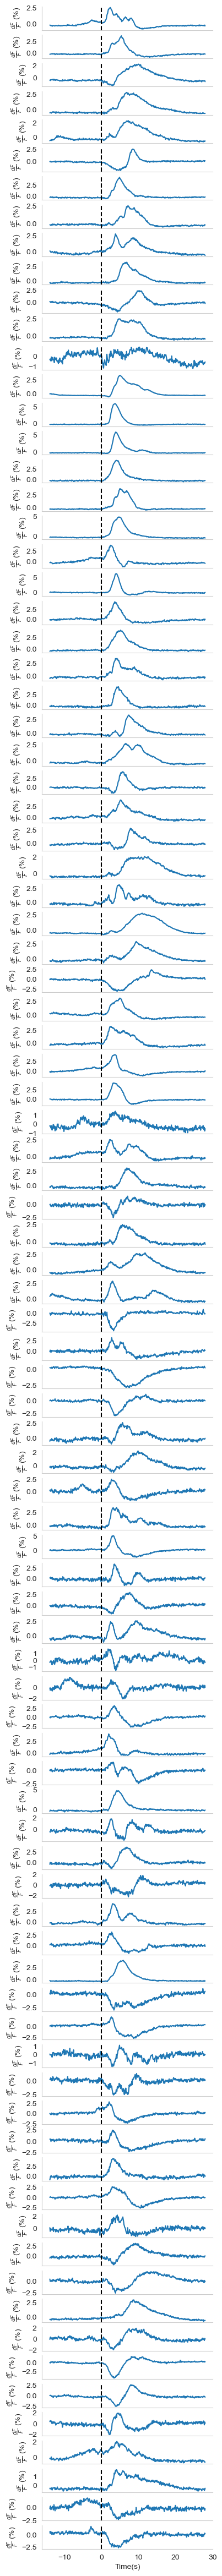

In [91]:
ax_fc, across_eta_fc, time_fc = onep.eta_individual_cells(data=fc_dfz, timestamps=astro7fc.Timestamps[:3303], events=[[120,180,240,300], ], window=28)

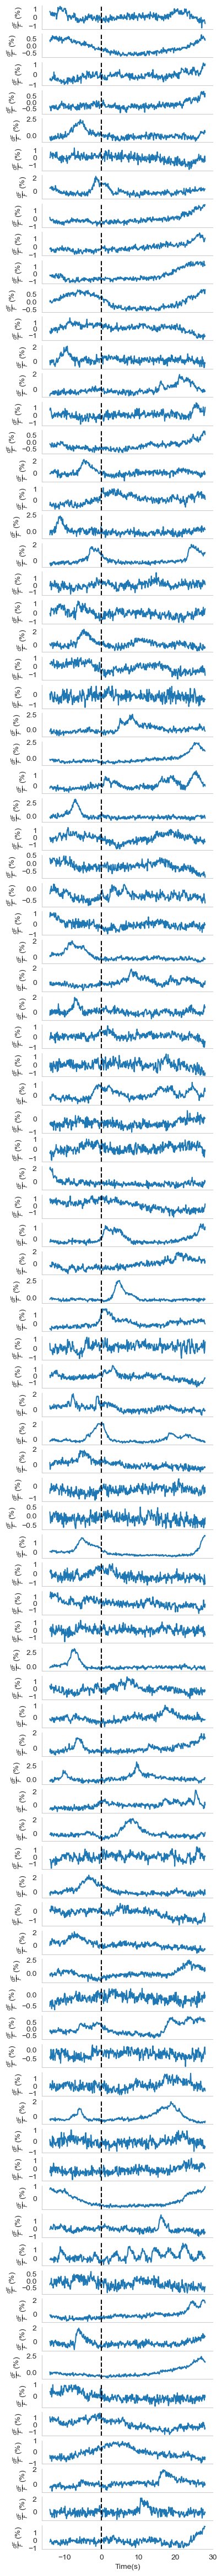

In [92]:
ax_recall, across_eta_recall, time_recall = onep.eta_individual_cells(data=recall_dfz, timestamps=astro7.Timestamps[:3303], events=[[120,180,240,300], ], window=28)

Text(52.722222222222214, 0.5, 'Cell #')

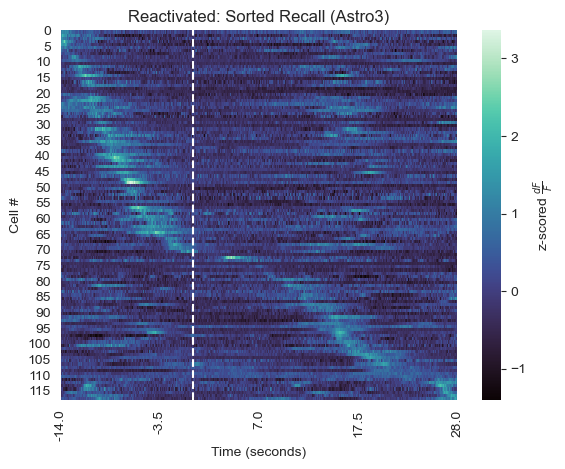

In [25]:
#Reactivated cells, sorted within recall
recall_idxs = np.argmax(across_eta_recall, axis=1)
dummy_idxs = np.arange(0, 118, 1) #number of both_idxs
dummy_table = np.hstack((recall_idxs.reshape(-1, 1), dummy_idxs.reshape(-1, 1)))
sorted_recall_idxs = np.argsort(dummy_table[:, 0])

sorted_arr = across_eta_recall[sorted_recall_idxs]
# sorted_arr = recall_dfz[sorted_recall_idxs] #plot entire thing
fig, ax = plt.subplots()
ax.axvline((time_recall.shape[0]/3), linestyle='--', color='white')
sns.heatmap(sorted_arr, cmap='mako',cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"})
ax.set_xticks(np.linspace(0, sorted_arr.shape[1], 5), np.linspace(np.min(time_recall), np.max(time_recall), 5))
ax.set_title('Reactivated: Sorted Recall (Astro3)')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')
# fig.savefig('/Users/suthardr/Desktop/Astro4_recall_fc_sorted.png')

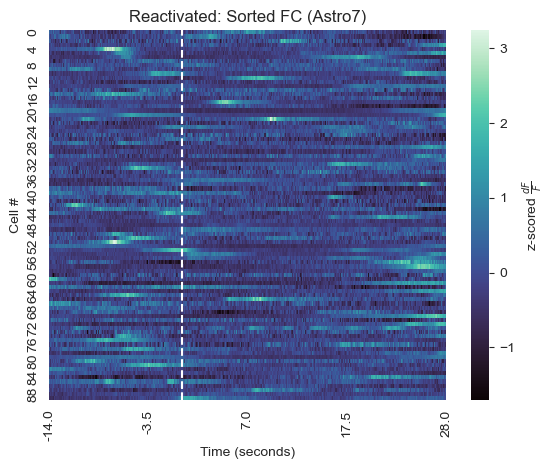

In [93]:
#Reactivated cells, sorted from FC
max_idxs = np.zeros(89)  #change based on # of overlapping cells
for i in range(across_eta_fc.shape[0]):
    idx = np.argmax(across_eta_fc[i])
    max_idxs[i] = idx
new_table = np.hstack((both_idxs, max_idxs.reshape(-1, 1)))
fc_idxs = np.argsort(new_table[:, 2])
###################
sorted_arr = across_eta_recall[fc_idxs] #plot just the eta times
# sorted_arr = recall_dfz[fc_idxs] #plot entire thing
fig, ax = plt.subplots()
ax.axvline((time_recall.shape[0]/3), linestyle='--', color='white')
sns.heatmap(sorted_arr, cmap='mako',cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"})
ax.set_xticks(np.linspace(0, sorted_arr.shape[1], 5), np.linspace(np.min(time_recall), np.max(time_recall), 5))
ax.set_title('Reactivated: Sorted FC (Astro8)') #119 overlapping cells
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')
fig.savefig('/Users/suthardr/Desktop/Astro8_recall_fc_sorted.png')

Text(52.722222222222214, 0.5, 'Cell #')

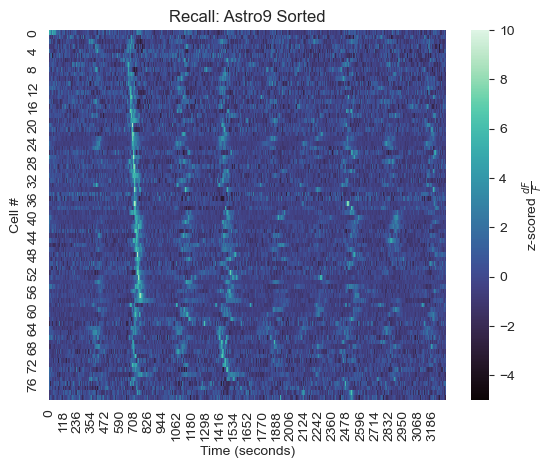

In [296]:
#sorted from FC
fc_tracesz = stats.zscore(recall_traces, axis=1)
max_indicesall = np.argmax(fc_tracesz, axis=1)
# time = np.linspace(-14, 28, 5)
sorted_ind = np.argsort(max_indicesall)
sorted_arr = fc_tracesz[sorted_ind]
fig, ax = plt.subplots()
# ax.axvline(x=42, color='white', linestyle='--')
# ax.axvline(x=105, color='white', linestyle='--')
sns.heatmap(sorted_arr, cmap='mako',cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"}, vmin=-5, vmax=10)
# ax.set_xticks(np.linspace(0, len(fc_tracesz.T), 5), time)
ax.set_title('Recall: Astro9 Sorted')
# ax.set_title('Recall Cells: Active FC-Recall Sorted from FC')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')

In [17]:
def detect_high_activity(df, n_seconds_to_discard, sampling_rate):
    # Discard the first n seconds
    df = df.loc[n_seconds_to_discard:, :]
    idx_offset = n_seconds_to_discard * sampling_rate
    # Sum activity across all cells at each time index
    activity_sum = df.sum(axis=1)
    # Calculate mean and standard deviation
    mean_activity = np.mean(activity_sum)
    std_activity = np.std(activity_sum)
    # Threshold for high activity
    threshold = mean_activity + 2 * std_activity
    # Get the indices of the peaks
    idxs = np.where(activity_sum > threshold)[0]
    idxs = idxs + idx_offset
    # Find sequences of 10 or more consecutive indices
    high_activity_periods = []
    consecutive_count = 0
    start_index = None
    for i in range(1, len(idxs)):
        # Check if current index is consecutive to the previous one
        if idxs[i] == idxs[i-1] + 1:
            consecutive_count += 1
            if consecutive_count == 1:
                start_index = idxs[i-1]
            if consecutive_count >= 10:
                if start_index is not None and start_index not in high_activity_periods:
                    high_activity_periods.append(start_index)
        else:
            consecutive_count = 0
            start_index = None
    return high_activity_periods, activity_sum

In [26]:
times, activity_sum = detect_high_activity(fc_dfz, 15, 10)
astro_3_fc.Timestamps[times]

AttributeError: 'numpy.ndarray' object has no attribute 'to_list'

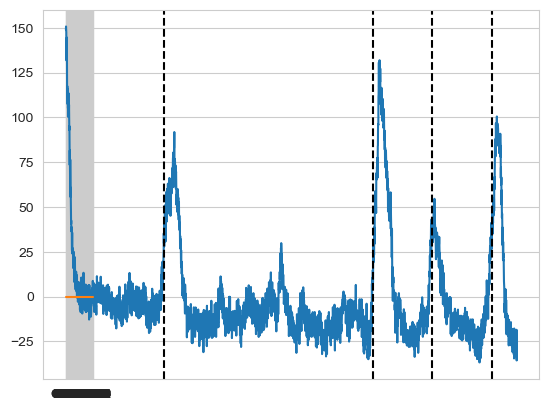

In [29]:
plt.plot(recall_dfz.sum(axis=0), label='Summed dF/F')
plt.axvline(x=720, color='black', linestyle='--')
plt.axvline(x=2250, color='black', linestyle='--')
plt.axvline(x=2680, color='black', linestyle='--')
plt.axvline(x=3120, color='black', linestyle='--')